In [1]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join

## now we add SpGEMM 3D into results

In [3]:
# permultter
# abspath = "/pscratch/sd/y/yuxihong/graphclustering/CombBLAS_YuxiPrivate/3DSpGEMM/perlmutter_exp/"
# chitu
abspath = "/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/3DSpGEMM/perlmutter_exp/"

### Plot random permutation time for each dataset

In [4]:
def generatedatamap(mpisize, permtype):
    curmap = {}
    with open(join(abspath,"newrun",f"run{mpisize}mpi_{permtype}.log"), 'r') as f:
        # if mpisize not in resmap:
        #     resmap[mpisize] = {}
        # if permtype not in resmap[mpisize]:
        #     resmap[mpisize][permtype] = {}
        
        while 1:
            line = f.readline()
            if not line:
                break

            # print(line)
            if line.startswith("reading mtx file"):
                line = line.strip("\n")
                print(line)
                name = line.split("/")[-1][:-4]
                if name not in curmap:
                    curmap[name] = {}
            # 2d AA results
            if line.startswith("Run 2d AA test"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("2DAA",name,val)
                curmap[name]["2DAA"] = float(val)
            # 1d AA results
            if line.startswith("Run 1d AA test"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("1DAA",name,val)
                curmap[name]["1DAA"] = float(val)
            # 3d AA results
            if line.startswith("Run AA3D_"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("3DAA-split",name,val)
                curmap[name]["3DAA-split"] = float(val)
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("3DAA-kernel",name,val)
                curmap[name]["3DAA-kernel"] = float(val)
            
            # 2d RTA 
            if line.startswith("Run 2d RT x A"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("2DRTA",name,val)
                curmap[name]["2DRTA"] = float(val)

            # 2d RTAR
            if line.startswith("Run 2d RTA x R"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("2DRTAR",name,val)
                curmap[name]["2DRTAR"] = float(val)
            # 1d RTA
            if line.startswith("Run 1d RT x A"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("1DRTA",name,val)
                curmap[name]["1DRTA"] = float(val)
            # 1d RTAR
            if line.startswith("Run RTAR 1D test!"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("1DRTAR",name,val)
                curmap[name]["1DRTAR"] = float(val)

            # 1d RTAR OP
            if line.startswith("Run RTAR 1D OP test!"):
                line = f.readline().strip("\n") # skip first spgemm
                
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("1DRTAROP-TransA",name,val)
                curmap[name]["1DRTAROP-TransA"] = float(val)
                
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("1DRTAROP-Kernel",name,val)
                curmap[name]["1DRTAROP-Kernel"] = float(val)
                
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("1DRTAROP-TransC",name,val)
                curmap[name]["1DRTAROP-TransC"] = float(val)

            # 3d RTA
            if line.startswith("Run RTA3D_"):
                
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("3DRTA-split",name,val)
                curmap[name]["3DRTA-split"] = float(val)

                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("3DRTA-kernel",name,val)
                curmap[name]["3DRTA-kernel"] = float(val)

            # 3d RTAR
            if line.startswith("Run RTAR3D_"):
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("3DRTAR-split",name,val)
                curmap[name]["3DRTAR-split"] = float(val)
                line = f.readline().strip("\n")
                val = line.split(' ')[-1]
                print("3DRTAR-kernel",name,val)
                curmap[name]["3DRTAR-kernel"] = float(val)

            if permtype == "randperm":
                if line.startswith("appying random permutation on matrix"):
                    line = f.readline().strip("\n")
                    val = line.split(' ')[-1]
                    print("randperm-genseq",name,val)
                    curmap[name]["randperm-genaeq"] = float(val)
                    line = f.readline().strip("\n")
                    val = line.split(' ')[-1]
                    print("randperm-perm2d",name,val)
                    curmap[name]["randperm-perm2d"] = float(val)
                    line = f.readline().strip("\n")
                    val = line.split(' ')[-1]
                    print("randperm-perm1d",name,val)
                    curmap[name]["randperm-perm1d"] = float(val)
    return curmap

In [5]:
datamap = {}
datamap["16"] = {}
datamap["64"] = {}
datamap["256"] = {}
datamap["16"]["randperm"] = generatedatamap(16, "randperm")
datamap["16"]["noperm"] = generatedatamap(16, "noperm")
datamap["64"]["randperm"] = generatedatamap(64, "randperm")
datamap["64"]["noperm"] = generatedatamap(64, "noperm")
datamap["256"]["randperm"] = generatedatamap(256, "randperm")
datamap["256"]["noperm"] = generatedatamap(256, "noperm")

reading mtx file /global/cfs/cdirs/m1982/yuxihong/spgemm1ddataset/mouse_gene.mtx
randperm-genseq mouse_gene 0.000886
randperm-perm2d mouse_gene 0.589
randperm-perm1d mouse_gene 0.0746
2DAA mouse_gene 1.86
1DAA mouse_gene 4.03
3DAA-split mouse_gene 0.25
3DAA-kernel mouse_gene 2.8
2DRTA mouse_gene 0.0651
2DRTAR mouse_gene 0.019
1DRTA mouse_gene 0.0281
1DRTAR mouse_gene 0.031
1DRTAROP-TransA mouse_gene 0.00802
1DRTAROP-Kernel mouse_gene 0.0071
1DRTAROP-TransC mouse_gene 0.000744
3DRTA-split mouse_gene 0.151
3DRTA-kernel mouse_gene 0.0918
3DRTAR-split mouse_gene 0.0125
3DRTAR-kernel mouse_gene 0.00951
reading mtx file /global/cfs/cdirs/m1982/yuxihong/spgemm1ddataset/ldoor.mtx
randperm-genseq ldoor 0.00252
randperm-perm2d ldoor 1.1
randperm-perm1d ldoor 0.129
2DAA ldoor 0.786
1DAA ldoor 0.973
3DAA-split ldoor 0.449
3DAA-kernel ldoor 0.863
2DRTA ldoor 0.122
2DRTAR ldoor 0.0227
1DRTA ldoor 0.0652
1DRTAR ldoor 0.186
1DRTAROP-TransA ldoor 0.00737
1DRTAROP-Kernel ldoor 0.00792
1DRTAROP-TransC ld

[3.21, 5.38, 12.9, 2.27, 2.11, 2.36]
[1.25, 0.783, 0.432, 0.754, 0.324, 0.221]
[3.77, 3.91, 4.84, 3.14, 3.4, 4.48]
[1.05, 0.65, 0.853, 2.02, 2.48, 16.9]


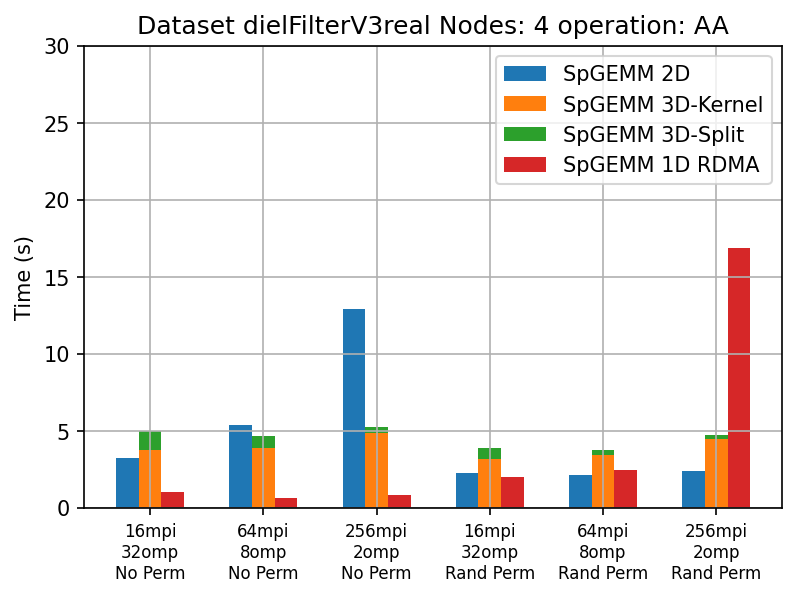

In [6]:
dataset = "dielFilterV3real"
test = 'AA'
perm = 'noperm'
sp2d_AA = []
sp3d_AAsplit = []
sp3d_AAkernel = []
sp1d_AA = []
genperm = []
doperm2d = []
doperm1d = []
for res in ['16','64','256']:
    sp2d_AA.append(datamap[res][perm][dataset]['2DAA'])
    sp3d_AAsplit.append(datamap[res][perm][dataset]['3DAA-split'])
    sp3d_AAkernel.append(datamap[res][perm][dataset]['3DAA-kernel'])
    sp1d_AA.append(datamap[res][perm][dataset]['1DAA'])
    genperm.append(0)
    doperm1d.append(0)
    doperm2d.append(0)

perm = 'randperm'
for res in ['16','64','256']:
    sp2d_AA.append(datamap[res][perm][dataset]['2DAA'])
    sp3d_AAsplit.append(datamap[res][perm][dataset]['3DAA-split'])
    sp3d_AAkernel.append(datamap[res][perm][dataset]['3DAA-kernel'])
    sp1d_AA.append(datamap[res][perm][dataset]['1DAA'])
    genperm.append(datamap[res][perm][dataset]['randperm-genaeq'])
    doperm2d.append(datamap[res][perm][dataset]["randperm-perm2d"])
    doperm1d.append(datamap[res][perm][dataset]["randperm-perm1d"])

print(sp2d_AA)
print(sp3d_AAsplit)
print(sp3d_AAkernel)
print(sp1d_AA)
plt.figure(figsize=(6,4),dpi=150)

plt.bar(np.arange(len(sp2d_AA))-0.2,sp2d_AA,width=0.2,label='SpGEMM 2D')
# bottom = np.array(sp2d_AA)
# plt.bar(np.arange(len(genperm))-0.2,genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(genperm))-0.2,doperm2d,width=0.2,label='Permute',bottom=bottom)

plt.bar(np.arange(len(sp3d_AAkernel)),sp3d_AAkernel,width=0.2,label='SpGEMM 3D-Kernel')
bottom = np.array(sp3d_AAkernel)
plt.bar(np.arange(len(sp3d_AAsplit)),sp3d_AAsplit,width=0.2,label='SpGEMM 3D-Split', bottom = bottom)
# bottom += np.array(sp3d_AAsplit)
# plt.bar(np.arange(len(genperm)),genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(genperm)),doperm2d,width=0.2,label='Permute',bottom=bottom)


plt.bar(np.arange(len(sp1d_AA))+0.2,sp1d_AA,width=0.2,label='SpGEMM 1D RDMA')
# bottom = np.array(sp1d_AA)
# plt.bar(np.arange(len(genperm))+0.2,genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(doperm1d))+0.2,doperm1d,width=0.2,label='Permute',bottom=bottom)


plt.grid()
plt.legend()
plt.ylabel("Time (s)")
plt.xticks(np.arange(len(sp1d_AA)),
           ['16mpi\n32omp\nNo Perm','64mpi\n8omp\nNo Perm',
            '256mpi\n2omp\nNo Perm','16mpi\n32omp\nRand Perm',
            '64mpi\n8omp\nRand Perm','256mpi\n2omp\nRand Perm'], fontsize=8)
mpisetting = '16mpi_no_perm'
# plt.title(r"Dataset {}, nnz(A)={:.2e}, nnz($A^2$)={:.2e}".format(dataset,AAnnz[mpisetting][0],AAnnz[mpisetting][2]))
plt.title(f"Dataset {dataset} Nodes: 4 operation: {test}")
plt.ylim([0,30])
plt.savefig(f"{dataset}_{test}.png",bbox_inches='tight')
plt.show()

In [ ]:
dataset = "dielFilterV3real"
test = 'RTA'
perm = 'noperm'
sp2d_AA = []
sp3d_AAsplit = []
sp3d_AAkernel = []
sp1d_AA = []
genperm = []
doperm2d = []
doperm1d = []
for res in ['16','64','256']:
    sp2d_AA.append(datamap[res][perm][dataset]['2DRTA'])
    sp3d_AAsplit.append(datamap[res][perm][dataset]['3DRTA-split'])
    sp3d_AAkernel.append(datamap[res][perm][dataset]['3DRTA-kernel'])
    sp1d_AA.append(datamap[res][perm][dataset]['1DRTA'])
    genperm.append(0)
    doperm1d.append(0)
    doperm2d.append(0)

perm = 'randperm'
for res in ['16','64','256']:
    sp2d_AA.append(datamap[res][perm][dataset]['2DRTA'])
    sp3d_AAsplit.append(datamap[res][perm][dataset]['3DRTA-split'])
    sp3d_AAkernel.append(datamap[res][perm][dataset]['3DRTA-kernel'])
    sp1d_AA.append(datamap[res][perm][dataset]['1DRTA'])
    genperm.append(datamap[res][perm][dataset]['randperm-genaeq'])
    doperm2d.append(datamap[res][perm][dataset]["randperm-perm2d"])
    doperm1d.append(datamap[res][perm][dataset]["randperm-perm1d"])

print(sp2d_AA)
print(sp3d_AAsplit)
print(sp3d_AAkernel)
print(sp1d_AA)
plt.figure(figsize=(6,4),dpi=150)

plt.bar(np.arange(len(sp2d_AA))-0.2,sp2d_AA,width=0.2,label='SpGEMM 2D')
# bottom = np.array(sp2d_AA)
# plt.bar(np.arange(len(genperm))-0.2,genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(genperm))-0.2,doperm2d,width=0.2,label='Permute',bottom=bottom)

plt.bar(np.arange(len(sp3d_AAkernel)),sp3d_AAkernel,width=0.2,label='SpGEMM 3D-Kernel')
bottom = np.array(sp3d_AAkernel)
plt.bar(np.arange(len(sp3d_AAsplit)),sp3d_AAsplit,width=0.2,label='SpGEMM 3D-Split', bottom = bottom)
# bottom += np.array(sp3d_AAsplit)
# plt.bar(np.arange(len(genperm)),genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(genperm)),doperm2d,width=0.2,label='Permute',bottom=bottom)


plt.bar(np.arange(len(sp1d_AA))+0.2,sp1d_AA,width=0.2,label='SpGEMM 1D RDMA')
# bottom = np.array(sp1d_AA)
# plt.bar(np.arange(len(genperm))+0.2,genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(doperm1d))+0.2,doperm1d,width=0.2,label='Permute',bottom=bottom)


plt.grid()
plt.legend()
plt.ylabel("Time (s)")
plt.xticks(np.arange(len(sp1d_AA)),
           ['16mpi\n32omp\nNo Perm','64mpi\n8omp\nNo Perm',
            '256mpi\n2omp\nNo Perm','16mpi\n32omp\nRand Perm',
            '64mpi\n8omp\nRand Perm','256mpi\n2omp\nRand Perm'], fontsize=8)
mpisetting = '16mpi_no_perm'
# plt.title(r"Dataset {}, nnz(A)={:.2e}, nnz($A^2$)={:.2e}".format(dataset,AAnnz[mpisetting][0],AAnnz[mpisetting][2]))
plt.title(f"Dataset {dataset} Nodes: 4 Operations: {test}")
# plt.ylim([0,30])
plt.savefig(f"{dataset}_{test}.png",bbox_inches='tight')
plt.show()

In [ ]:
dataset = "delaunay_n24"
test = 'RTAR'
perm = 'noperm'
sp2d_AA = []
sp3d_AAsplit = []
sp3d_AAkernel = []
sp1d_TransA = []
sp1d_Kernel = []
sp1d_TransC = []
genperm = []
doperm2d = []
doperm1d = []
for res in ['16','64','256']:
    sp2d_AA.append(datamap[res][perm][dataset]['2DRTAR'])
    sp3d_AAsplit.append(datamap[res][perm][dataset]['3DRTAR-split'])
    sp3d_AAkernel.append(datamap[res][perm][dataset]['3DRTAR-kernel'])
    sp1d_TransA.append(datamap[res][perm][dataset]['1DRTAROP-TransA'])
    sp1d_TransC.append(datamap[res][perm][dataset]['1DRTAROP-TransC'])
    sp1d_Kernel.append(datamap[res][perm][dataset]['1DRTAROP-Kernel'])
    genperm.append(0)
    doperm1d.append(0)
    doperm2d.append(0)

perm = 'randperm'
for res in ['16','64','256']:
    sp2d_AA.append(datamap[res][perm][dataset]['2DRTAR'])
    sp3d_AAsplit.append(datamap[res][perm][dataset]['3DRTAR-split'])
    sp3d_AAkernel.append(datamap[res][perm][dataset]['3DRTAR-kernel'])
    sp1d_TransA.append(datamap[res][perm][dataset]['1DRTAROP-TransA'])
    sp1d_TransC.append(datamap[res][perm][dataset]['1DRTAROP-TransC'])
    sp1d_Kernel.append(datamap[res][perm][dataset]['1DRTAROP-Kernel'])
    genperm.append(datamap[res][perm][dataset]['randperm-genaeq'])
    doperm2d.append(datamap[res][perm][dataset]["randperm-perm2d"])
    doperm1d.append(datamap[res][perm][dataset]["randperm-perm1d"])

# print(sp2d_AA)
# print(sp3d_AAsplit)
# print(sp3d_AAkernel)
# print(sp1d_AA)
plt.figure(figsize=(6,4),dpi=150)

plt.bar(np.arange(len(sp2d_AA))-0.2,sp2d_AA,width=0.2,label='SpGEMM 2D')
# bottom = np.array(sp2d_AA)
# plt.bar(np.arange(len(genperm))-0.2,genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(genperm))-0.2,doperm2d,width=0.2,label='Permute',bottom=bottom)

plt.bar(np.arange(len(sp3d_AAkernel)),sp3d_AAkernel,width=0.2,label='SpGEMM 3D-Kernel')
bottom = np.array(sp3d_AAkernel)
plt.bar(np.arange(len(sp3d_AAsplit)),sp3d_AAsplit,width=0.2,label='SpGEMM 3D-Split', bottom = bottom)
# bottom += np.array(sp3d_AAsplit)
# plt.bar(np.arange(len(genperm)),genperm,width=0.2,label='Generate Random Permutation',bottom=bottom)
# bottom += np.array(genperm)
# plt.bar(np.arange(len(genperm)),doperm2d,width=0.2,label='Permute',bottom=bottom)


plt.bar(np.arange(len(sp1d_Kernel))+0.2,sp1d_Kernel,width=0.2,label='SpGEMM 1D RDMA')
bottom = np.array(sp1d_Kernel)
plt.bar(np.arange(len(sp1d_TransA))+0.2,sp1d_TransA,width=0.2,label='Transpose A',bottom=bottom)
bottom += np.array(sp1d_TransA)
plt.bar(np.arange(len(sp1d_TransC))+0.2,sp1d_TransC,width=0.2,label='Transpose C',bottom=bottom)


plt.grid()
plt.legend()
plt.ylabel("Time (s)")
plt.xticks(np.arange(len(sp1d_AA)),
           ['16mpi\n32omp\nNo Perm','64mpi\n8omp\nNo Perm',
            '256mpi\n2omp\nNo Perm','16mpi\n32omp\nRand Perm',
            '64mpi\n8omp\nRand Perm','256mpi\n2omp\nRand Perm'], fontsize=8)
mpisetting = '16mpi_no_perm'
# plt.title(r"Dataset {}, nnz(A)={:.2e}, nnz($A^2$)={:.2e}".format(dataset,AAnnz[mpisetting][0],AAnnz[mpisetting][2]))
plt.title(f"Dataset {dataset} Nodes: 4 Operations: {test}")
# plt.ylim([0,30])
plt.savefig(f"{dataset}_{test}.png",bbox_inches='tight')
plt.show()